In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xarray as xr
import tensorly as tl
from DisjointTucker import DisjointTucker
from DisjointTuckerArgmax import DisjointTuckerArgmax
from LassoTucker import LassoTucker

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

def compute_fit(decomposition, X):
    """Returns fit of tucker decomposition in percent"""
    core, factors = decomposition
    return 100 - 100 * tl.norm(tl.tucker_to_tensor((core, factors)) - X) / tl.norm(X)

def print_latex(df):
    print(df.to_latex(index=False,
                  formatters={"name": str.upper},
                  float_format="{:.1f}".format,
                  ))

In [3]:
%load_ext autoreload
%autoreload 2

In [2]:
data = xr.open_dataarray('tensor_df_6.nc')
data_tensor = data.values
map_region    = dict(enumerate(data.coords['object_name'].values))
map_indicator = dict(enumerate(data.coords['indicator_name'].values))
map_year      = dict(enumerate(data.coords['year'].values))
print("Размеры:", data.sizes)

Размеры: Frozen({'object_name': 85, 'indicator_name': 16, 'year': 6})


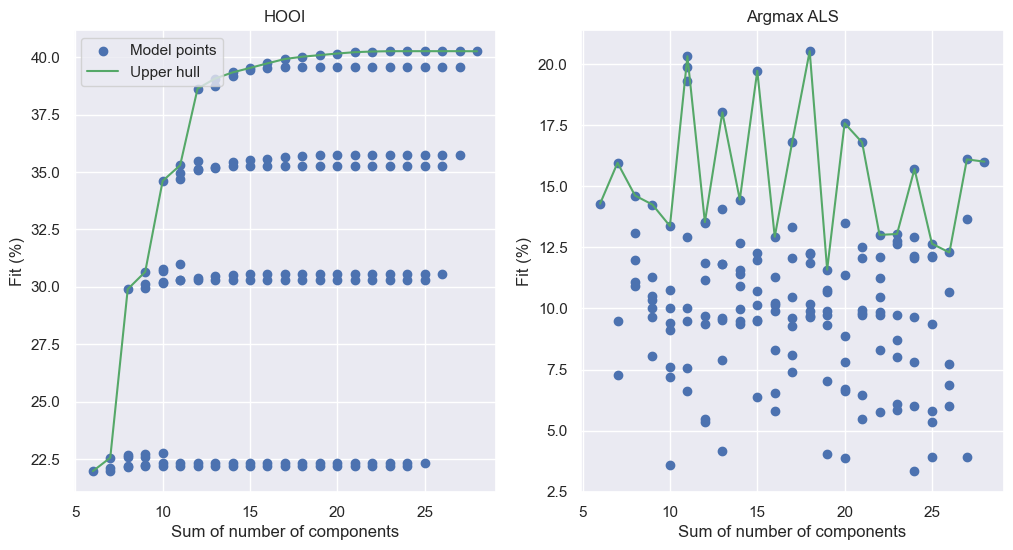

In [3]:
regions_clusters_values = list(range(2, 21))
indicator_clusters_values = list(range(2, 6))
year_clusters_values = [2, 3]

df_fits = pd.DataFrame(columns=['P', 'Q', 'R', 'Sum of components', 'Fit (Regular)', 'Fit (Argmax)'])
reg_fits = dict()
argmax_fits = dict()

for P in regions_clusters_values:
    for Q in indicator_clusters_values:
        for R in year_clusters_values:
            core, factors = tl.decomposition.tucker(data_tensor, rank=[P, Q, R])
            rec = tl.tucker_to_tensor((core, factors))
            fit = (1 - tl.norm(rec - data_tensor)/tl.norm(data_tensor)) * 100

            model = DisjointTuckerArgmax(ranks=[P, Q, R], disjoint_modes=[0, 1, 2])
            core, factors = model.fit_transform(data_tensor)
            fit_argmax = model.compute_fit(data_tensor) * 100

            S = P + Q + R
            df_fits.loc[len(df_fits)] = [P, Q, R, S, fit, fit_argmax]
            if S in reg_fits:
                reg_fits[S].append(fit)
                argmax_fits[S].append(fit_argmax)
            else:
                reg_fits[S] = [fit]
                argmax_fits[S] = [fit_argmax]

df_fits = df_fits.sort_values(by=['Fit (Regular)'], ascending=False)
fig, (ax0, ax1) = plt.subplots(1, 2)
max_reg_fits = dict()
max_argmax_fits = dict()
labeled = False
for key in reg_fits:
    ax0.scatter([key] * len(reg_fits[key]), reg_fits[key], color='b', label='Model points' if not labeled else None)
    labeled = True
    max_reg_fits[key] = max(reg_fits[key])
for key in argmax_fits:
    ax1.scatter([key] * len(argmax_fits[key]), argmax_fits[key], color='b')
    max_argmax_fits[key] = max(argmax_fits[key])
ax0.plot(max_reg_fits.keys(), max_reg_fits.values(), color='g', label='Upper hull')
ax1.plot(max_argmax_fits.keys(), max_argmax_fits.values(), color='g')
ax0.legend()
ax0.set_ylabel('Fit (%)')
ax1.set_xlabel('Sum of number of components')
ax0.set_xlabel('Sum of number of components')
ax1.set_ylabel('Fit (%)')
ax0.set_title("HOOI")
ax1.set_title("Argmax ALS")
plt.show()

In [4]:
display(df_fits[df_fits['Sum of components'] == 11])

,P,Q,R,Sum of components,Fit (Regular),Fit (Argmax)
22,4.0,5.0,2.0,11.0,35.292421,19.879246
28,5.0,4.0,2.0,11.0,34.955522,12.909231
21,4.0,4.0,3.0,11.0,34.688581,20.314257
15,3.0,5.0,3.0,11.0,30.982573,19.308743
34,6.0,3.0,2.0,11.0,30.288255,9.492566
27,5.0,3.0,3.0,11.0,30.286042,6.619149
33,6.0,2.0,3.0,11.0,22.340716,7.563735
40,7.0,2.0,2.0,11.0,22.187029,10.014738


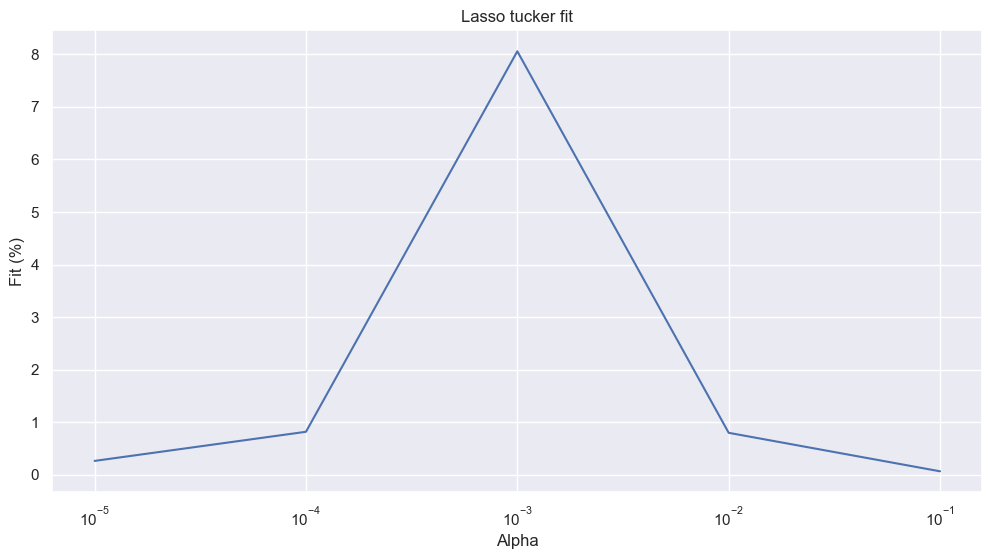

Best alpha 0.001 with fit 8.06%


In [14]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
from LassoTucker import LassoTucker

P, Q, R = 4, 4, 3
alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
lasso_fits = []
for alpha in alphas:
    model = LassoTucker(ranks=[P, Q, R], random_state=42, disjoint_modes=[0, 1, 2], alpha=alpha)
    core, factors = model.fit_transform(data_tensor)
    lasso_fits.append(compute_fit((core, factors), data_tensor))
plt.plot(alphas, lasso_fits, scalex='log')
plt.xlabel('Alpha')
plt.ylabel('Fit (%)')
plt.title('Lasso tucker fit')
plt.xscale('log')
plt.show()

print(f"Best alpha {alphas[np.argmax(lasso_fits)]} with fit {np.max(lasso_fits):.2f}%")

In [15]:
from itertools import chain, combinations

def powerset(iterable):
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))

df_dj_fits = pd.DataFrame(columns=['Disjoint modes', 'Region clusters', 'Fit (PCA)', 'Fit (Argmax)'])
rows = []
for modes in powerset([0, 1, 2]):
    modes = list(modes)
    P, Q, R = 4, 4, 3
    model = DisjointTucker(
        ranks=[P, Q, R],
        random_state=42,
        disjoint_modes=modes,
    )
    core_dj, factors_dj = model.fit_transform(data_tensor)
    pca_fit = compute_fit((core_dj, factors_dj), data_tensor)
    P, Q, R = 4, 4, 3
    model = DisjointTuckerArgmax(
        ranks=[P, Q, R],
        disjoint_modes=modes,
    )
    core_dj, factors_dj = model.fit_transform(data_tensor)
    argmax_fit = compute_fit((core_dj, factors_dj), data_tensor)
    
    rows.append({
        'Disjoint modes': str(modes),
        'Fit (DisjointPCA ALS)': f"{pca_fit:.2f}%",
        'Fit (Argmax ALS)': f"{argmax_fit:.2f}%"
    })

df_dj_fits = pd.DataFrame(rows).reset_index(drop=True)
display(df_dj_fits)


,Disjoint modes,Fit (DisjointPCA ALS),Fit (Argmax ALS)
0,[],34.69%,34.69%
1,[0],27.12%,26.46%
2,[1],26.54%,23.72%
3,[2],34.63%,22.10%
4,"[0, 1]",22.02%,20.81%
5,"[0, 2]",27.08%,17.11%
6,"[1, 2]",26.50%,15.50%
7,"[0, 1, 2]",22.00%,20.31%


Regular fit: 34.69%
DisjointPCA fit: 22.00%
DisjointArgmax fit: 20.31%


Text(0.5, 1.0, 'Factor 3, Argmax ALS')

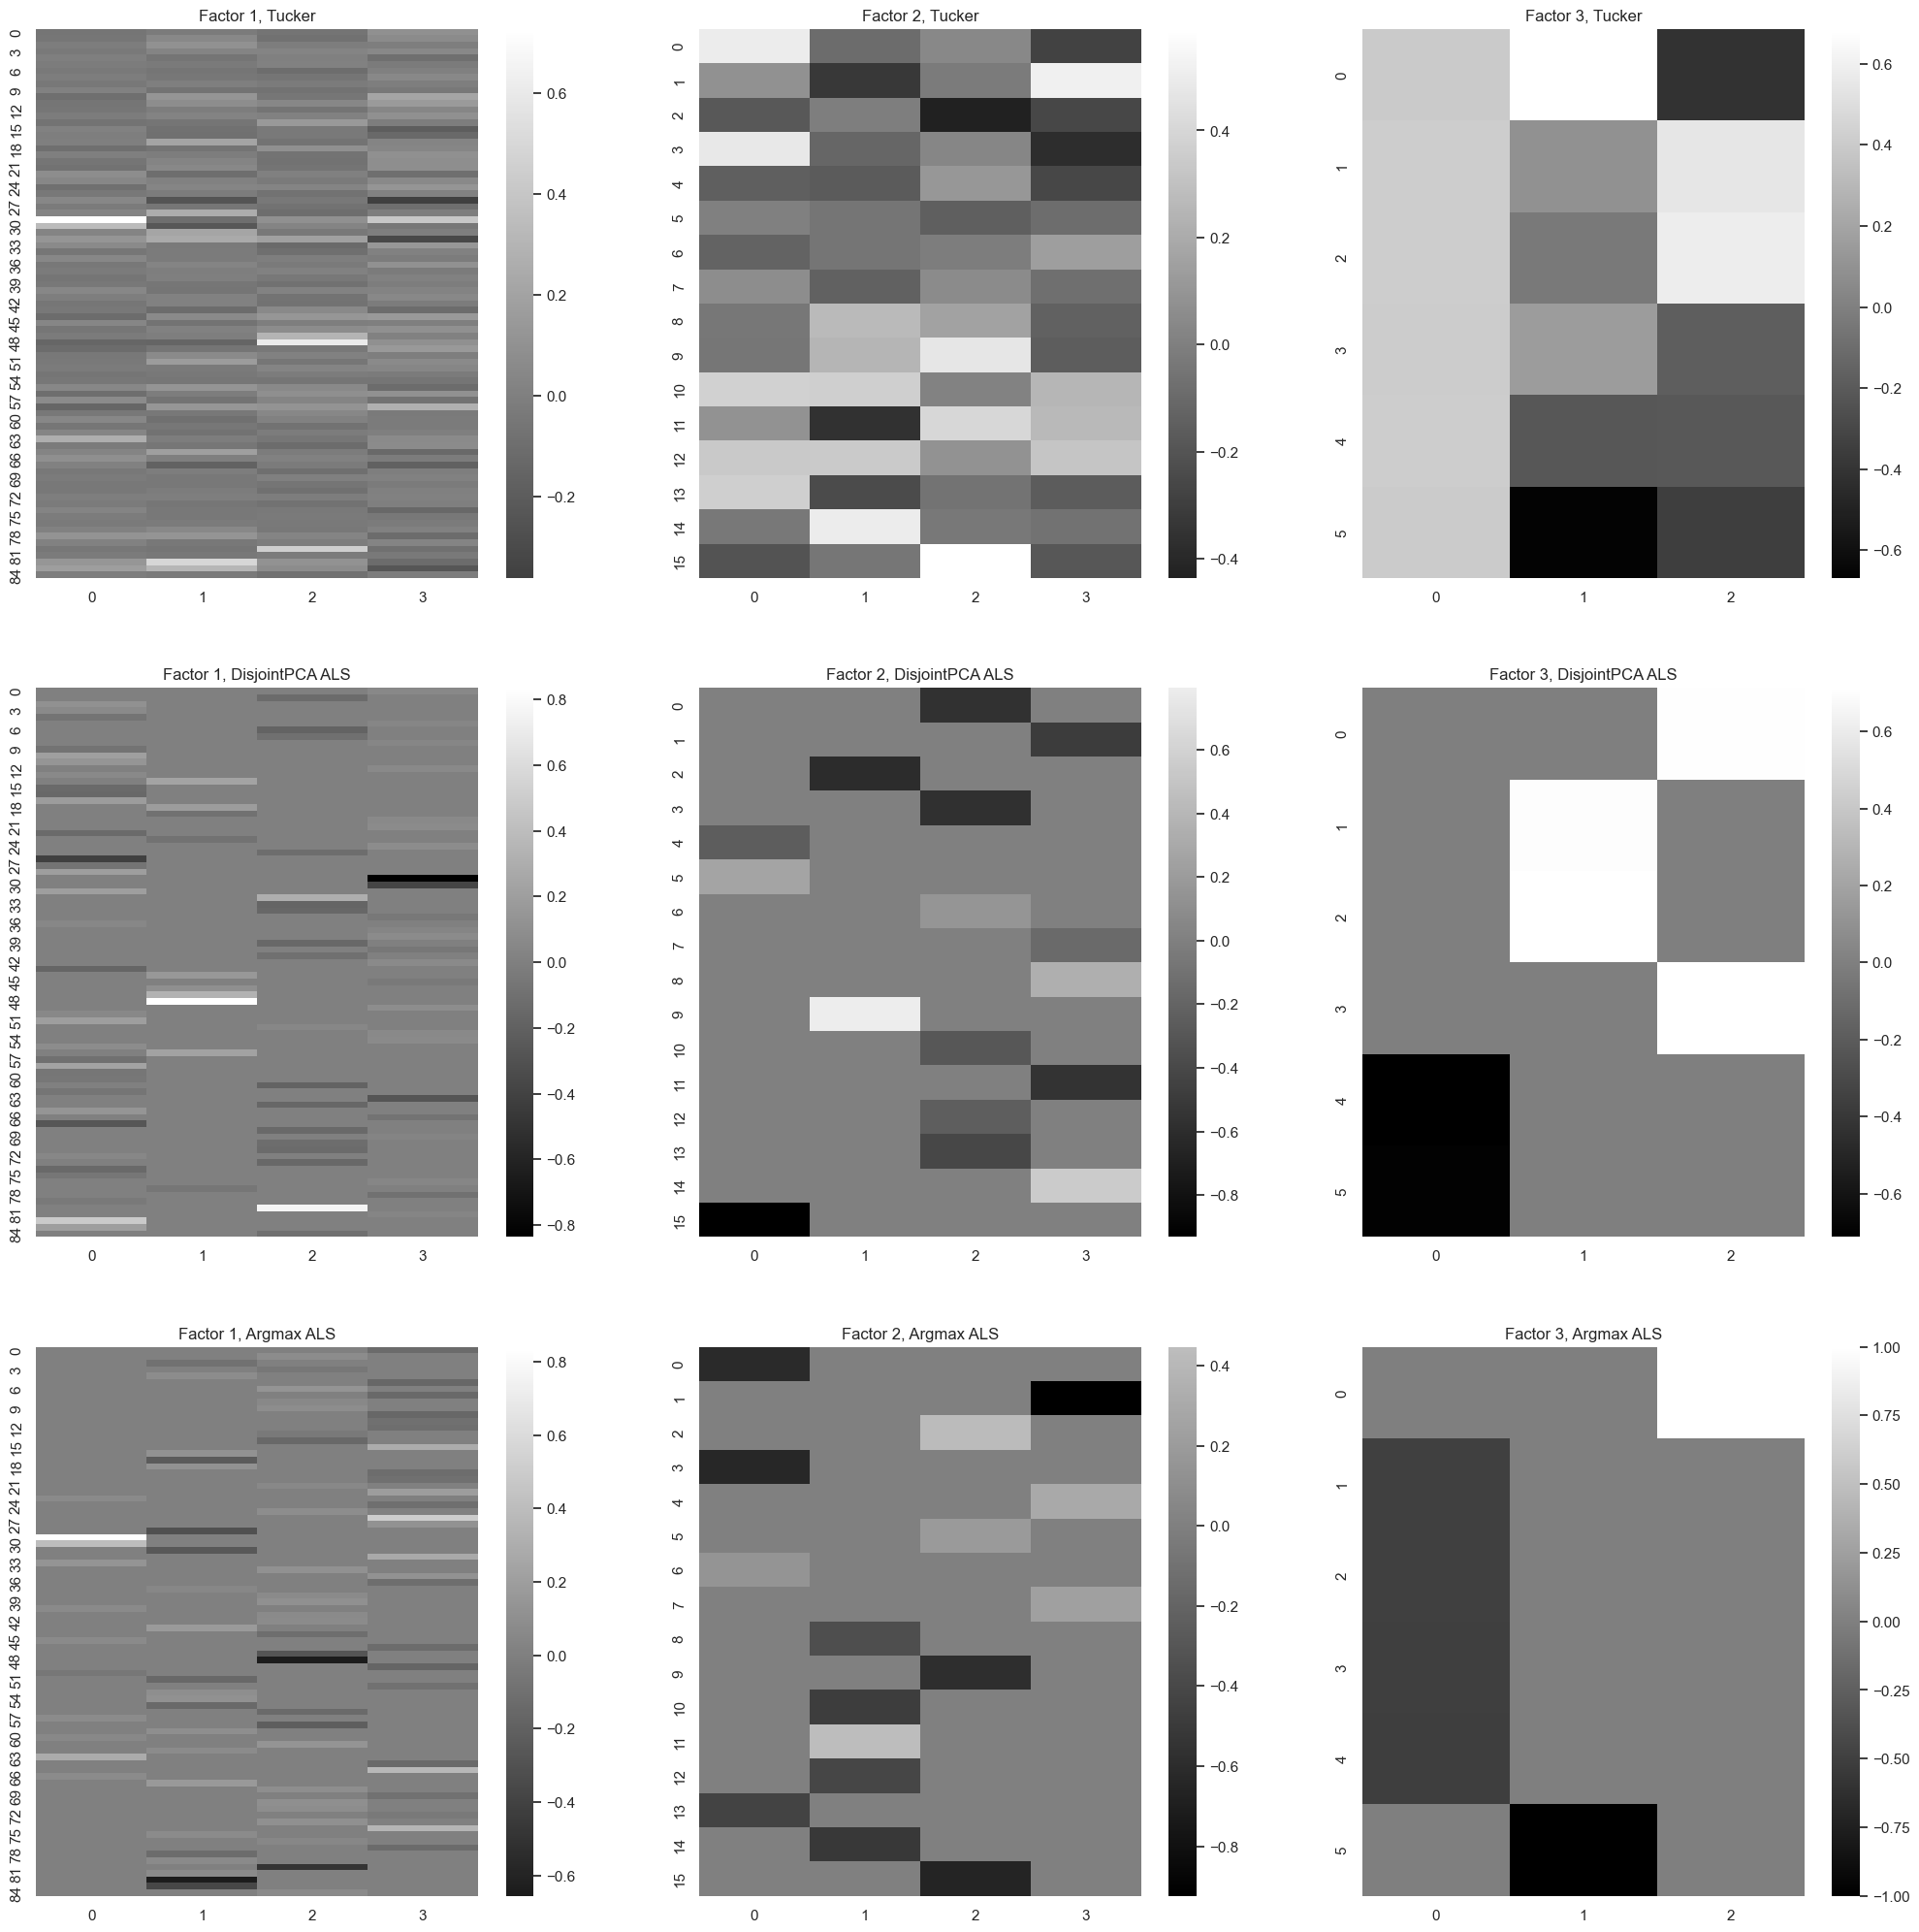

In [16]:
from DisjointTuckerArgmax import DisjointTuckerArgmax
from DisjointTucker import DisjointTucker
import tensorly as tl
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(25, 25))

P, Q, R = 4, 4, 3
core_std, factors_std = tl.decomposition.tucker(data_tensor, rank=[P, Q, R], random_state=42)
print(f"Regular fit: {compute_fit((core_std, factors_std), data_tensor):.2f}%")
sns.heatmap(factors_std[0], cmap='grey', ax=axs[0, 0], center=0)
sns.heatmap(factors_std[1], cmap='grey', ax=axs[0, 1], center=0)
sns.heatmap(factors_std[2], cmap='grey', ax=axs[0, 2], center=0)

model = DisjointTucker(
        ranks=[P, Q, R],
        random_state=42,
        disjoint_modes=[0, 1, 2],
    )
core_pca, factors_pca = model.fit_transform(data_tensor)
print(f"DisjointPCA fit: {compute_fit((core_pca, factors_pca), data_tensor):.2f}%")
sns.heatmap(factors_pca[0], cmap='grey', ax=axs[1, 0], center=0)
sns.heatmap(factors_pca[1], cmap='grey', ax=axs[1, 1], center=0)
sns.heatmap(factors_pca[2], cmap='grey', ax=axs[1, 2], center=0)

model = DisjointTuckerArgmax(
        ranks=[P, Q, R],
        disjoint_modes=[0, 1, 2],
    )
core_argmax, factors_argmax = model.fit_transform(data_tensor)
print(f"DisjointArgmax fit: {compute_fit((core_argmax, factors_argmax), data_tensor):.2f}%")
sns.heatmap(factors_argmax[0], cmap='grey', ax=axs[2, 0], center=0)
sns.heatmap(factors_argmax[1], cmap='grey', ax=axs[2, 1], center=0)
sns.heatmap(factors_argmax[2], cmap='grey', ax=axs[2, 2], center=0)





axs[0, 0].set_title("Factor 1, Tucker")
axs[0, 1].set_title("Factor 2, Tucker")
axs[0, 2].set_title("Factor 3, Tucker")

axs[1, 0].set_title("Factor 1, DisjointPCA ALS")
axs[1, 1].set_title("Factor 2, DisjointPCA ALS")
axs[1, 2].set_title("Factor 3, DisjointPCA ALS")

axs[2, 0].set_title("Factor 1, Argmax ALS")
axs[2, 1].set_title("Factor 2, Argmax ALS")
axs[2, 2].set_title("Factor 3, Argmax ALS")

In [ ]:
df_regions = pd.DataFrame({
    'region': data.coords['object_name'].values,
})
df_indicators = pd.DataFrame({
    'indicator': data.coords['indicator_name'].values,
})
df_years = pd.DataFrame({
    'year': data.coords['year'].values,
})

for i in range(P):
    df_regions[f'COMP-A{i+1}_std']    = factors_std[0][:, i]
for i in range(P):
    df_regions[f'COMP-A{i+1}_pca']    = factors_pca[0][:, i]
for i in range(P):
    df_regions[f'COMP-A{i+1}_argmax'] = factors_argmax[0][:, i]

for i in range(Q):
    df_indicators[f'COMP-B{i+1}_std']    = factors_std[1][:, i]
for i in range(Q):
    df_indicators[f'COMP-B{i+1}_pca']    = factors_pca[1][:, i]
for i in range(Q):
    df_indicators[f'COMP-B{i+1}_argmax'] = factors_argmax[1][:, i]

for i in range(R):
    df_years[f'COMP-C{i+1}_std']    = factors_std[2][:, i]
for i in range(R):
    df_years[f'COMP-C{i+1}_pca']    = factors_pca[2][:, i]
for i in range(R):
    df_years[f'COMP-C{i+1}_argmax'] = factors_argmax[2][:, i]

df_regions['cluster_pca']    = np.argmax(np.abs(factors_pca[0]),    axis=1) + 1
df_regions['cluster_argmax'] = np.argmax(np.abs(factors_argmax[0]), axis=1) + 1

df_indicators['cluster_pca']    = np.argmax(np.abs(factors_pca[1]),    axis=1) + 1
df_indicators['cluster_argmax'] = np.argmax(np.abs(factors_argmax[1]), axis=1) + 1

df_years['cluster_pca']    = np.argmax(np.abs(factors_pca[2]),    axis=1) + 1
df_years['cluster_argmax'] = np.argmax(np.abs(factors_argmax[2]), axis=1) + 1


def print_clusters(df, entity_col, methods):
    headers = {'pca': 'DisjointPCA', 'argmax': 'Argmax'}
    section_headers = {
        'region':    'КЛАСТЕРЫ РЕГИОНОВ',
        'indicator': 'КЛАСТЕРЫ ПОКАЗАТЕЛЕЙ',
        'year':      'КЛАСТЕРЫ ЛЕТ',
    }
    print(section_headers[entity_col])

    for method in methods:
        col = f'cluster_{method}'
        print(f"\n {headers[method]}:")
        for c in sorted(df[col].unique()):
            items = df[df[col] == c][entity_col].tolist()
            if entity_col == 'year':
                print(f"    [Кластер {c}]: {items}")
            else:
                print(f"\n    [Кластер {c}] ({len(items)}):")
                for item in items:
                    print(f"      • {item}")


print_clusters(df_regions,    'region',    ['pca', 'argmax'])
print_clusters(df_indicators, 'indicator', ['pca', 'argmax'])
print_clusters(df_years,      'year',      ['pca', 'argmax'])

# Код сгенерирован при помощи LLM Qwen

КЛАСТЕРЫ РЕГИОНОВ

 DisjointPCA:

    [Кластер 1] (33):
      • Архангельская область (без автономного округа)
      • Астраханская область
      • Белгородская область
      • Воронежская область
      • Еврейская автономная область
      • Забайкальский край
      • Иркутская область
      • Калининградская область
      • Калужская область
      • Камчатский край
      • Краснодарский край
      • Ленинградская область
      • Липецкая область
      • Магаданская область
      • Мурманская область
      • Омская область
      • Республика Адыгея
      • Республика Карелия
      • Республика Коми
      • Республика Саха (Якутия)
      • Республика Татарстан
      • Республика Тыва
      • Республика Хакасия
      • Ростовская область
      • Самарская область
      • Сахалинская область
      • Севастополь
      • Томская область
      • Тюменская область (без автономных округов)
      • Удмуртская Республика
      • Челябинская область
      • Чукотский автономный округ
      • Ямал

C:\Users\vorkm\AppData\Local\Temp\ipykernel_20396\3835878043.py:97: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



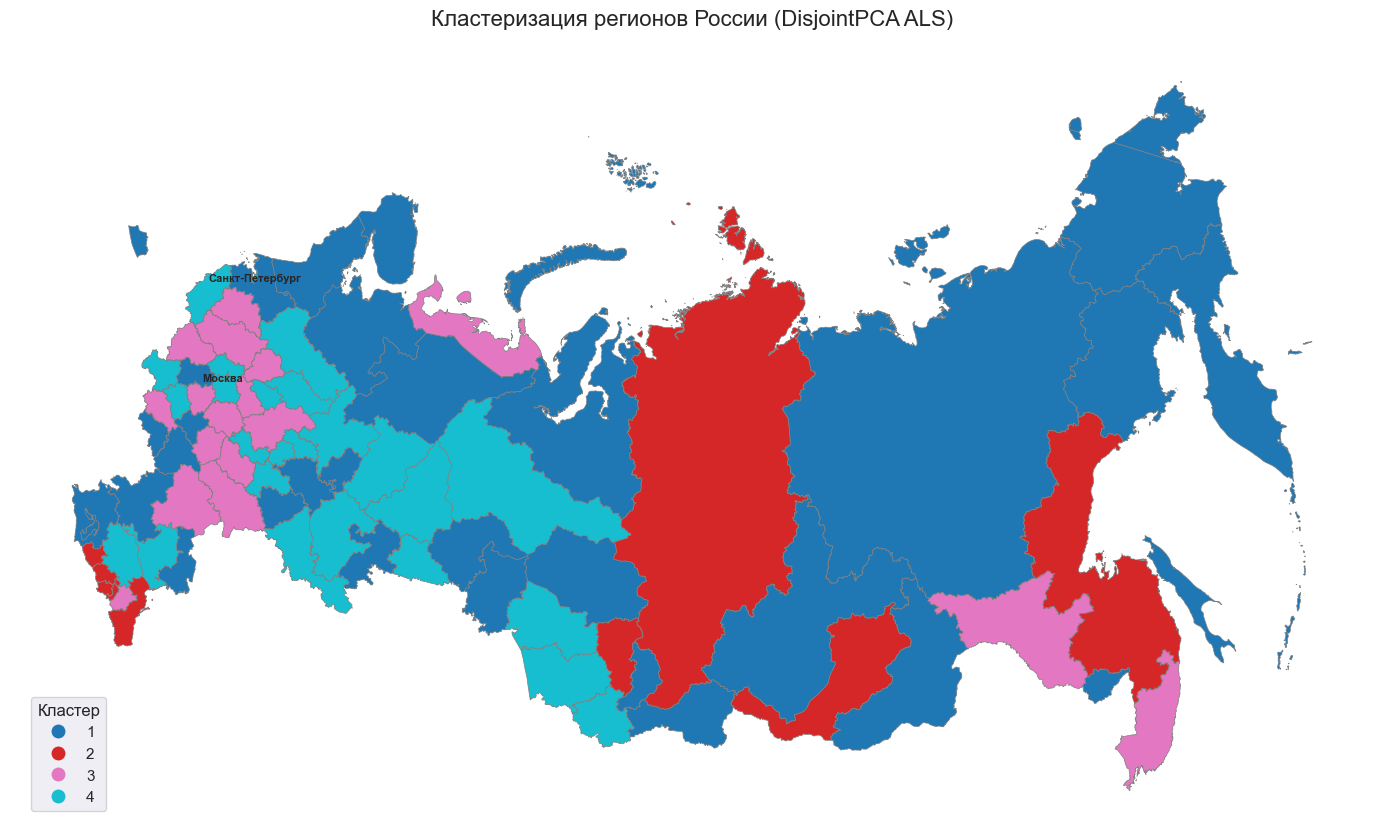

In [ ]:
import os
os.environ["SHAPE_RESTORE_SHX"] = "YES"

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from thefuzz import process

GEOJSON_URL = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/russia.geojson"
gdf = gpd.read_file(GEOJSON_URL)
region_col = "name" 

NAME_FIXES = {
    # ==============================
    # РЕСПУБЛИКИ: короткая → полная форма
    # ==============================
    "Адыгея": "Республика Адыгея",
    "Алтай": "Республика Алтай",
    "Башкортостан": "Республика Башкортостан",
    "Бурятия": "Республика Бурятия",
    "Дагестан": "Республика Дагестан",
    "Ингушетия": "Республика Ингушетия",
    "Марий Эл": "Республика Марий Эл",
    "Мордовия": "Республика Мордовия",
    "Татарстан": "Республика Татарстан",
    "Тыва": "Республика Тыва",
    "Хакасия": "Республика Хакасия",
    "Чувашия": "Чувашская Республика",
    
    # ==============================
    # ИСПРАВЛЕНИЕ РЕГИСТРА (республика → Республика)
    # ==============================
    "Карачаево-Черкесская республика": "Карачаево-Черкесская Республика",
    "Чеченская республика": "Чеченская Республика",
    "Кабардино-Балкарская республика": "Кабардино-Балкарская Республика",
    "Удмуртская республика": "Удмуртская Республика",
    
    # ==============================
    # РАЗНЫЕ ТИРЕ / ДЕФИСЫ / ПРОБЕЛЫ
    # ==============================
    # В GeoJSON: обычный дефис "-", в данных: длинное тире "—"
    "Ханты-Мансийский автономный округ - Югра": "Ханты-Мансийский автономный округ — Югра",
    
    # Северная Осетия: разное написание тире + добавление "Республика"
    "Северная Осетия - Алания": "Республика Северная Осетия — Алания",
    
    # ==============================
    # ОБЛАСТИ С УТОЧНЕНИЯМИ В СКОБКАХ
    # ==============================
    # В ваших данных эти области указаны без автономных округов
    "Тюменская область": "Тюменская область (без автономных округов)",
    "Архангельская область": "Архангельская область (без автономного округа)",
}

gdf["object_name"] = gdf[region_col].replace(NAME_FIXES)
gdf.loc[gdf[region_col] == "Чувашия", region_col] = "Чувашская Республика"

rosstat_names = df_regions["region"].tolist()
gis_names = gdf[region_col].tolist()

mapping = {}
for gis_name in gis_names:
    best_match, score = process.extractOne(gis_name, rosstat_names)
    if score > 85:  
        mapping[gis_name] = best_match

gdf["object_name"] = gdf[region_col].map(mapping).fillna(gdf[region_col])


# 3. Слияние с кластерами регионов
# df_regions должен быть из предыдущего шага: pd.DataFrame({'region': ..., 'cluster': ...})
gdf = gdf.merge(df_regions, left_on="object_name", right_on="region", how="left")

# Проверяем, сколько регионов не смёржилось
missing = gdf[gdf["cluster_pca"].isna()][region_col].tolist()
if missing:
    print(f"⚠️ Не удалось сопоставить {len(missing)} регионов:")
    for m in missing[:5]: print(f"  • {m}")
    print("  💡 Добавьте их в NAME_FIXES или используйте fuzzy-matching (см. ниже)")

# Загружаем данные (в географических координатах)
gdf = gdf.to_crs(epsg=4326)  # убеждаемся, что исходные координаты в WGS84

# Репроекция: центрируем на Восточной Сибири (~100° в.д., 60° с.ш.)
# Используем Azimuthal Equidistant — сохраняет направления от центра
gdf_proj = gdf.to_crs(
    f"+proj=aeqd +lat_0=60 +lon_0=100 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
)

gdf = gdf_proj

# 4. Визуализация
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
n_clusters = gdf["cluster_pca"].nunique()
cmap = plt.cm.get_cmap("tab10", n_clusters)

gdf.plot(
    column="cluster_pca",
    categorical=True,
    cmap=cmap,
    ax=ax,
    linewidth=0.5,
    edgecolor="gray",
    legend=True,
    legend_kwds={"loc": "lower left", "title": "Кластер", "bbox_to_anchor": (0.01, 0.01)}
)

ax.set_title("Кластеризация регионов России (DisjointPCA ALS)", fontsize=16, pad=15)
ax.axis("off")

# Добавляем подписи для крупных регионов (опционально)
for _, row in gdf.iterrows():
    if pd.notna(row["cluster_pca"]) and row["name"] in ["Москва", "Санкт-Петербург"]:
        ax.text(row["geometry"].centroid.x, row["geometry"].centroid.y, 
                row["name"], ha="center", va="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig("russia_clusters_map_pca.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Экспорт результата (GeoJSON с кластерами)
gdf[["object_name", "cluster_pca", "geometry"]].dropna(subset=["cluster_pca"]).to_file("russia_clusters_pca.geojson", driver="GeoJSON")

# Код сгенерирован при помощи LLM Qwen

C:\Users\vorkm\AppData\Local\Temp\ipykernel_20396\3265101845.py:97: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



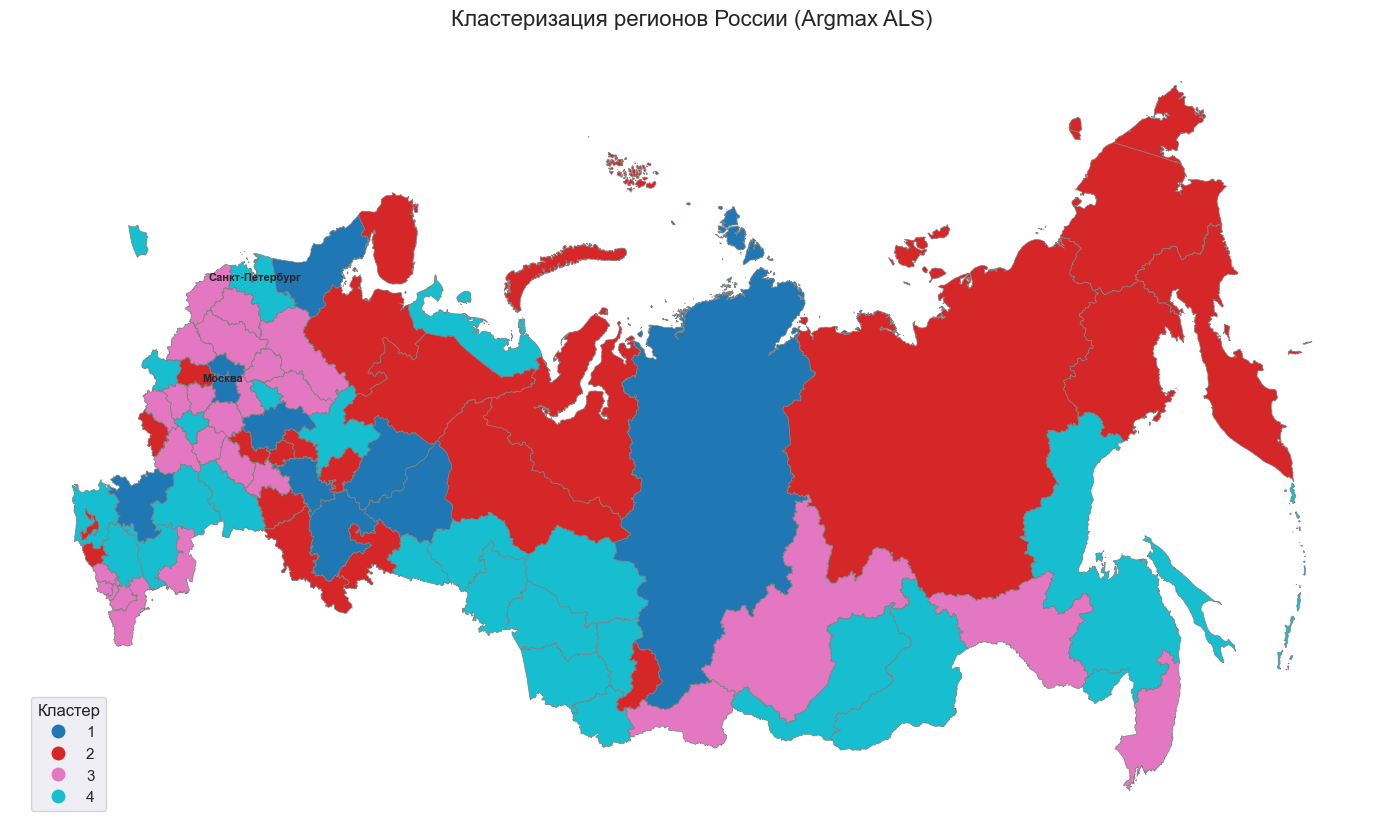

In [ ]:
import os
os.environ["SHAPE_RESTORE_SHX"] = "YES"

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from thefuzz import process

GEOJSON_URL = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/russia.geojson"
gdf = gpd.read_file(GEOJSON_URL)
region_col = "name" 

NAME_FIXES = {
    # ==============================
    # РЕСПУБЛИКИ: короткая → полная форма
    # ==============================
    "Адыгея": "Республика Адыгея",
    "Алтай": "Республика Алтай",
    "Башкортостан": "Республика Башкортостан",
    "Бурятия": "Республика Бурятия",
    "Дагестан": "Республика Дагестан",
    "Ингушетия": "Республика Ингушетия",
    "Марий Эл": "Республика Марий Эл",
    "Мордовия": "Республика Мордовия",
    "Татарстан": "Республика Татарстан",
    "Тыва": "Республика Тыва",
    "Хакасия": "Республика Хакасия",
    "Чувашия": "Чувашская Республика",
    
    # ==============================
    # ИСПРАВЛЕНИЕ РЕГИСТРА (республика → Республика)
    # ==============================
    "Карачаево-Черкесская республика": "Карачаево-Черкесская Республика",
    "Чеченская республика": "Чеченская Республика",
    "Кабардино-Балкарская республика": "Кабардино-Балкарская Республика",
    "Удмуртская республика": "Удмуртская Республика",
    
    # ==============================
    # РАЗНЫЕ ТИРЕ / ДЕФИСЫ / ПРОБЕЛЫ
    # ==============================
    # В GeoJSON: обычный дефис "-", в данных: длинное тире "—"
    "Ханты-Мансийский автономный округ - Югра": "Ханты-Мансийский автономный округ — Югра",
    
    # Северная Осетия: разное написание тире + добавление "Республика"
    "Северная Осетия - Алания": "Республика Северная Осетия — Алания",
    
    # ==============================
    # ОБЛАСТИ С УТОЧНЕНИЯМИ В СКОБКАХ
    # ==============================
    # В ваших данных эти области указаны без автономных округов
    "Тюменская область": "Тюменская область (без автономных округов)",
    "Архангельская область": "Архангельская область (без автономного округа)",
}

gdf["object_name"] = gdf[region_col].replace(NAME_FIXES)
gdf.loc[gdf[region_col] == "Чувашия", region_col] = "Чувашская Республика"

rosstat_names = df_regions["region"].tolist()
gis_names = gdf[region_col].tolist()

mapping = {}
for gis_name in gis_names:
    best_match, score = process.extractOne(gis_name, rosstat_names)
    if score > 85:  
        mapping[gis_name] = best_match

gdf["object_name"] = gdf[region_col].map(mapping).fillna(gdf[region_col])


# 3. Слияние с кластерами регионов
# df_regions должен быть из предыдущего шага: pd.DataFrame({'region': ..., 'cluster': ...})
gdf = gdf.merge(df_regions, left_on="object_name", right_on="region", how="left")

# Проверяем, сколько регионов не смёржилось
missing = gdf[gdf["cluster_argmax"].isna()][region_col].tolist()
if missing:
    print(f"⚠️ Не удалось сопоставить {len(missing)} регионов:")
    for m in missing[:5]: print(f"  • {m}")
    print("  💡 Добавьте их в NAME_FIXES или используйте fuzzy-matching (см. ниже)")

# Загружаем данные (в географических координатах)
gdf = gdf.to_crs(epsg=4326)  # убеждаемся, что исходные координаты в WGS84

# Репроекция: центрируем на Восточной Сибири (~100° в.д., 60° с.ш.)
# Используем Azimuthal Equidistant — сохраняет направления от центра
gdf_proj = gdf.to_crs(
    f"+proj=aeqd +lat_0=60 +lon_0=100 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
)

gdf = gdf_proj

# 4. Визуализация
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
n_clusters = gdf["cluster_argmax"].nunique()
cmap = plt.cm.get_cmap("tab10", n_clusters)

gdf.plot(
    column="cluster_argmax",
    categorical=True,
    cmap=cmap,
    ax=ax,
    linewidth=0.5,
    edgecolor="gray",
    legend=True,
    legend_kwds={"loc": "lower left", "title": "Кластер", "bbox_to_anchor": (0.01, 0.01)}
)

ax.set_title("Кластеризация регионов России (Argmax ALS)", fontsize=16, pad=15)
ax.axis("off")

# Добавляем подписи для крупных регионов (опционально)
for _, row in gdf.iterrows():
    if pd.notna(row["cluster_argmax"]) and row["name"] in ["Москва", "Санкт-Петербург"]:
        ax.text(row["geometry"].centroid.x, row["geometry"].centroid.y, 
                row["name"], ha="center", va="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig("russia_clusters_map_argmax.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Экспорт результата (GeoJSON с кластерами)
gdf[["object_name", "cluster_argmax", "geometry"]].dropna(subset=["cluster_argmax"]).to_file("russia_clusters_argmax.geojson", driver="GeoJSON")

# Код сгенерирован при помощи LLM Qwen